In [4]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.circuit.library import QNNCircuit

from qiskit_machine_learning.neural_networks import EstimatorQNN
#The EstimatorQNN is a neural network that takes in a parametrized quantum circuit with designated
#parameters for input data and/or weights, an optional observable(s) and outputs their expectation value(s).
#circuit is built from two circuits: a feature map, which provides input parameters for the network, and an ansatz (weight parameters)

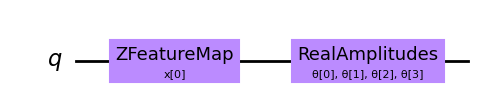

[[-0.7684976]]


In [99]:
num_qubits = 1

# Using the QNNCircuit:
# Create a parameterized 1 qubit circuit composed of the default ZZFeatureMap feature map
# and RealAmplitudes ansatz.
qnn_qc = QNNCircuit(num_qubits)
display(qnn_qc.draw('mpl'))

qnn = EstimatorQNN(
    circuit=qnn_qc  # passing QNNCircuit as a parameter inside EstimatorQNN
)
display(qnn)
result=qnn.forward(input_data=[5], weights=[8,7,6,5])
print(result)


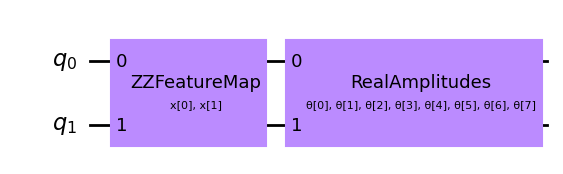

[[0.32999572]]


In [39]:
num_qubits = 2

# Using the QNNCircuit:
# Create a parameterized 2 qubit circuit composed of the default ZZFeatureMap feature map
# and RealAmplitudes ansatz.
qnn_qc = QNNCircuit(num_qubits)
display(qnn_qc.draw('mpl'))

qnn = EstimatorQNN(
    circuit=qnn_qc  # passing QNNCircuit as a parameter inside EstimatorQNN
)
display(qnn)
result=qnn.forward(input_data=[5,5], weights=[8,7,6,5,4,3,2,1])
print(result)


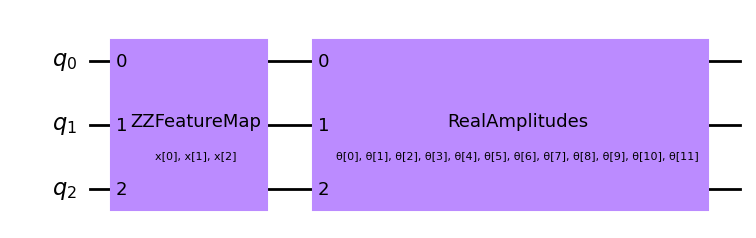

[[0.32274434]]


In [43]:
num_qubits = 3

# Using the QNNCircuit:
# Create a parameterized 2 qubit circuit composed of the default ZZFeatureMap feature map
# and RealAmplitudes ansatz.
qnn_qc = QNNCircuit(num_qubits)
display(qnn_qc.draw('mpl'))

qnn = EstimatorQNN(
    circuit=qnn_qc  # passing QNNCircuit as a parameter inside EstimatorQNN
)
display(qnn)
result=qnn.forward(input_data=[3,3,4], weights=[1, 2, 3, 4, 5, 6, 7, 8,9,10,11,12])
print(result)

In [41]:
# Explicitly specifying the ansatz and feature map:  instead of sending QNNCircuit:
feature_map = ZZFeatureMap(feature_dimension=num_qubits)
ansatz = RealAmplitudes(num_qubits=num_qubits)

qc = QuantumCircuit(num_qubits)    
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters
)

qnn.forward(input_data=[1, 2], weights=[1, 2, 3, 4, 5, 6, 7, 8])

array([[0.33039274]])

In [44]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.circuit.library import QNNCircuit

from qiskit_machine_learning.neural_networks import SamplerQNN

num_qubits = 2

def parity(x):
    return f"{bin(x)}".count("1") % 2

# Using the QNNCircuit:
# Create a parameterized 2 qubit circuit composed of the default ZZFeatureMap feature map
# and RealAmplitudes ansatz.
qnn_qc = QNNCircuit(num_qubits)

qnn = SamplerQNN(
    circuit=qnn_qc,
    interpret=parity,
    output_shape=2
)

qnn.forward(input_data=[1, 2], weights=[1, 2, 3, 4, 5, 6, 7, 8])



array([[0.66519637, 0.33480363]])

In [45]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.circuit.library import QNNCircuit

from qiskit_machine_learning.neural_networks import SamplerQNN

num_qubits = 2
# Explicitly specifying the ansatz and feature map:
feature_map = ZZFeatureMap(feature_dimension=num_qubits)
ansatz = RealAmplitudes(num_qubits=num_qubits)

qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

qnn = SamplerQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    interpret=parity,
    output_shape=2
)

qnn.forward(input_data=[1, 2], weights=[1, 2, 3, 4, 5, 6, 7, 8])

array([[0.66519637, 0.33480363]])

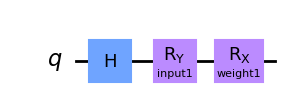

Number of input features for EstimatorQNN: 1 
Input: [0.29168892]
Number of trainable weights for EstimatorQNN: 1 
Weights: [0.13569851]
Forward pass result for EstimatorQNN: [[0.07780639]]. 
Shape: (1, 1)
Forward pass batched result for EstimatorQNN: [[0.07780639]
 [0.07780639]].  
Shape: (2, 1)
Input gradients for EstimatorQNN: None.  
Shape: None
Weight gradients for EstimatorQNN: [[[0.56985321]]].  
Shape: (1, 1, 1)
Input gradients for EstimatorQNN: [[[0.25913608]]].  
Shape: (1, 1, 1)
Weight gradients for EstimatorQNN: [[[0.56985321]]].  
Shape: (1, 1, 1)


In [84]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit
from qiskit_algorithms.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import EstimatorQNN

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(1)
qc1.h(0) #hadarmard gate
qc1.ry(params1[0], 0)
qc1.rx(params1[1], 0)
display(qc1.draw("mpl"))

from qiskit.quantum_info import SparsePauliOp
observable1 = SparsePauliOp.from_list([("Y" * qc1.num_qubits, 2)])


from qiskit_machine_learning.neural_networks import EstimatorQNN

estimator_qnn = EstimatorQNN(
    circuit=qc1, observables=observable1, input_params=[params1[0]], weight_params=[params1[1]]
)
estimator_qnn

estimator_qnn_input = algorithm_globals.random.random(estimator_qnn.num_inputs)
estimator_qnn_weights = algorithm_globals.random.random(estimator_qnn.num_weights)

#How to Run a Forward Pass
print(f"Number of input features for EstimatorQNN: {estimator_qnn.num_inputs} \nInput: {estimator_qnn_input}")
print(f"Number of trainable weights for EstimatorQNN: {estimator_qnn.num_weights} \nWeights: {estimator_qnn_weights}")

#Non-batched Forward Pass
estimator_qnn_forward = estimator_qnn.forward(estimator_qnn_input, estimator_qnn_weights)
print(f"Forward pass result for EstimatorQNN: {estimator_qnn_forward}. \nShape: {estimator_qnn_forward.shape}")

#batched Forward Pass
estimator_qnn_forward_batched = estimator_qnn.forward([estimator_qnn_input, estimator_qnn_input], estimator_qnn_weights)
print(f"Forward pass batched result for EstimatorQNN: {estimator_qnn_forward_batched}.  \nShape: {estimator_qnn_forward_batched.shape}")

#run a backward  Pass
estimator_qnn_input_grad, estimator_qnn_weight_grad = estimator_qnn.backward(estimator_qnn_input, estimator_qnn_weights)
print(f"Input gradients for EstimatorQNN: {estimator_qnn_input_grad}.  \nShape: {estimator_qnn_input_grad}")
print(f"Weight gradients for EstimatorQNN: {estimator_qnn_weight_grad}.  \nShape: {estimator_qnn_weight_grad.shape}")

# Backward Pass with Input Gradients
estimator_qnn.input_gradients = True
estimator_qnn.input_gradients = True
estimator_qnn_input_grad, estimator_qnn_weight_grad = estimator_qnn.backward(estimator_qnn_input, estimator_qnn_weights)
print(f"Input gradients for EstimatorQNN: {estimator_qnn_input_grad}.  \nShape: {estimator_qnn_input_grad.shape}")
print(f"Weight gradients for EstimatorQNN: {estimator_qnn_weight_grad}.  \nShape: {estimator_qnn_weight_grad.shape}")

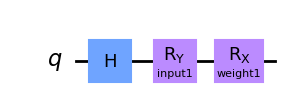

Number of input features for SamplerQNN: 1 
Input: [0.21977997]
Number of trainable weights for SamplerQNN: 1 
Weights: [0.96448248]
Forward pass result for SamplerQNN: [[0.43788295 0.56211705]
 [0.43788295 0.56211705]].  
Shape: (2, 2)
Input gradients for SamplerQNN: None.  
Shape: None
Weight gradients for SamplerQNN: [[[ 0.08957732]
  [-0.08957732]]].  
Shape: (1, 2, 1)
Input gradients for SamplerQNN: [[[-0.27806746]
  [ 0.27806746]]].  
Shape: (1, 2, 1)
Weight gradients for SamplerQNN: [[[ 0.08957732]
  [-0.08957732]]].  
Shape: (1, 2, 1)


In [96]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit
from qiskit_algorithms.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import EstimatorQNN

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(1)
qc1.h(0) #hadarmard gate
qc1.ry(params1[0], 0)
qc1.rx(params1[1], 0)
display(qc1.draw("mpl"))

from qiskit.quantum_info import SparsePauliOp
observable1 = SparsePauliOp.from_list([("Y" * qc1.num_qubits, 2)])

from qiskit_machine_learning.neural_networks import SamplerQNN
sampler_qnn = SamplerQNN(circuit=qc1, input_params=[params1[0]], weight_params=[params1[1]])
sampler_qnn

sampler_qnn_input = algorithm_globals.random.random(sampler_qnn.num_inputs)
sampler_qnn_weights = algorithm_globals.random.random(sampler_qnn.num_weights)

print(f"Number of input features for SamplerQNN: {sampler_qnn.num_inputs} \nInput: {sampler_qnn_input}")
print(f"Number of trainable weights for SamplerQNN: {sampler_qnn.num_weights} \nWeights: {sampler_qnn_weights}")
#batched Forward Pass
sampler_qnn_forward_batched = sampler_qnn.forward([sampler_qnn_input, sampler_qnn_input], sampler_qnn_weights)
print(f"Forward pass result for SamplerQNN: {sampler_qnn_forward_batched}.  \nShape: {sampler_qnn_forward_batched.shape}")
#run a backward  Pass
sampler_qnn_input_grad, sampler_qnn_weight_grad = sampler_qnn.backward(sampler_qnn_input, sampler_qnn_weights)
print(f"Input gradients for SamplerQNN: {sampler_qnn_input_grad}.  \nShape: {sampler_qnn_input_grad}")
print(f"Weight gradients for SamplerQNN: {sampler_qnn_weight_grad}.  \nShape: {sampler_qnn_weight_grad.shape}")

# Backward Pass with Input Gradients
sampler_qnn.input_gradients = True
sampler_qnn_input_grad, sampler_qnn_weight_grad = sampler_qnn.backward(sampler_qnn_input, sampler_qnn_weights)
print(f"Input gradients for SamplerQNN: {sampler_qnn_input_grad}.  \nShape: {sampler_qnn_input_grad.shape}")
print(f"Weight gradients for SamplerQNN: {sampler_qnn_weight_grad}.  \nShape: {sampler_qnn_weight_grad.shape}")

In [ ]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(1)
qc1.x(0)  #not gate
qc1.ry(params1[0], 0)
qc1.rx(params1[1], 0)
qc1.draw("mpl")

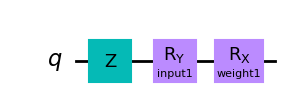

In [51]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(1)
qc1.z(0)  #not gate
qc1.ry(params1[0], 0)
qc1.rx(params1[1], 0)
qc1.draw("mpl")

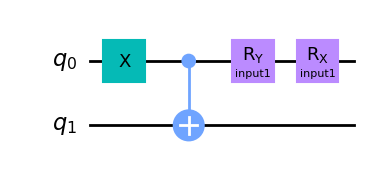

In [60]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(2)
qc1.x(0)  #not gate
qc1.cx(0,1)
qc1.ry(params1[0], 0)
qc1.rx(params1[0], 0)
qc1.draw("mpl")



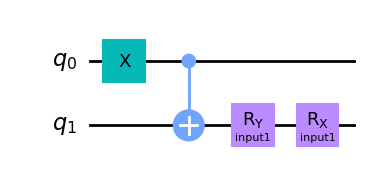

In [61]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(2)
qc1.x(0)  #not gate
qc1.cx(0,1)
qc1.ry(params1[0], 1)
qc1.rx(params1[0], 1)
qc1.draw("mpl")

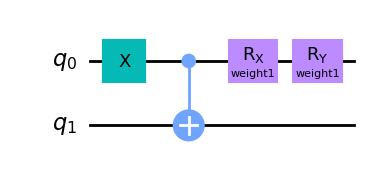

In [100]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(2)
qc1.x(0)  #not gate
qc1.cx(0,1)
qc1.rx(params1[1], 0)
qc1.ry(params1[1], 0)
qc1.draw("mpl")

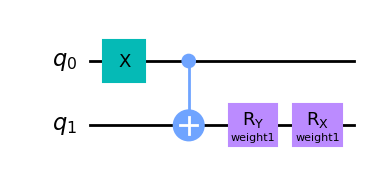

In [63]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(2)
qc1.x(0)  #not gate
qc1.cx(0,1)
qc1.ry(params1[1], 1)
qc1.rx(params1[1], 1)
qc1.draw("mpl")

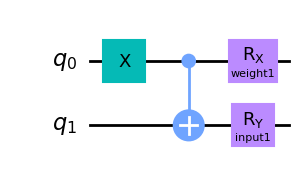

In [64]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(2)
qc1.x(0)  #not gate
qc1.cx(0,1)
qc1.ry(params1[0], 1)
qc1.rx(params1[1], 0)
qc1.draw("mpl")

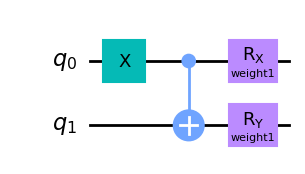

In [65]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(2)
qc1.x(0)  #not gate
qc1.cx(0,1)
qc1.ry(params1[1], 1)
qc1.rx(params1[1], 0)
qc1.draw("mpl")

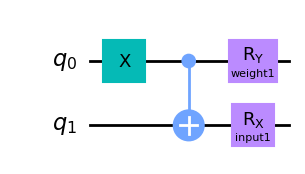

In [66]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(2)
qc1.x(0)  #not gate
qc1.cx(0,1)
qc1.ry(params1[1], 0)
qc1.rx(params1[0], 1)
qc1.draw("mpl")

In [97]:
import qiskit.tools.jupyter

%qiskit_version_table
%qiskit_copyright